In [1]:
import torch
import glob

import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src.models import RobustDetector

BATCH_SIZE = 1
TRANSFORM = "stft"

ckpt_path = f"checkpoints/robustdetector-{TRANSFORM}-use_conv.ckpt"

ai_dir = "data/test/attack/ai/"
human_dir = "data/test/attack/human/"

ai_paths = glob.glob(f"{ai_dir}/*.npz", recursive=True)
human_paths = glob.glob(f"{human_dir}/*.npz", recursive=True)

# load the model from the checkpoint
model = RobustDetector.load_from_checkpoint(ckpt_path)
model.eval()

# Extract linear weights (1, feature_dim)
weights = model.linear_proj.weights.detach().cpu().numpy().squeeze()
freqs = model.freqs.detach().cpu().numpy()
mask = model.mask.cpu().numpy()
freqs = freqs[mask]

ai_file = np.load(ai_paths[0])
ai_fps = ai_file[TRANSFORM][:BATCH_SIZE, mask]
#ai_fps = np.clip(ai_fps, a_min=None, a_max=8)
ai_fps_norm = F.normalize(torch.tensor(ai_fps), dim=-1).numpy()

human_file = np.load(human_paths[0])
human_fps = human_file[TRANSFORM][:BATCH_SIZE, mask]
#human_fps = np.clip(human_fps, a_min=None, a_max=8)
human_fps_norm = F.normalize(torch.tensor(human_fps), dim=-1).numpy()

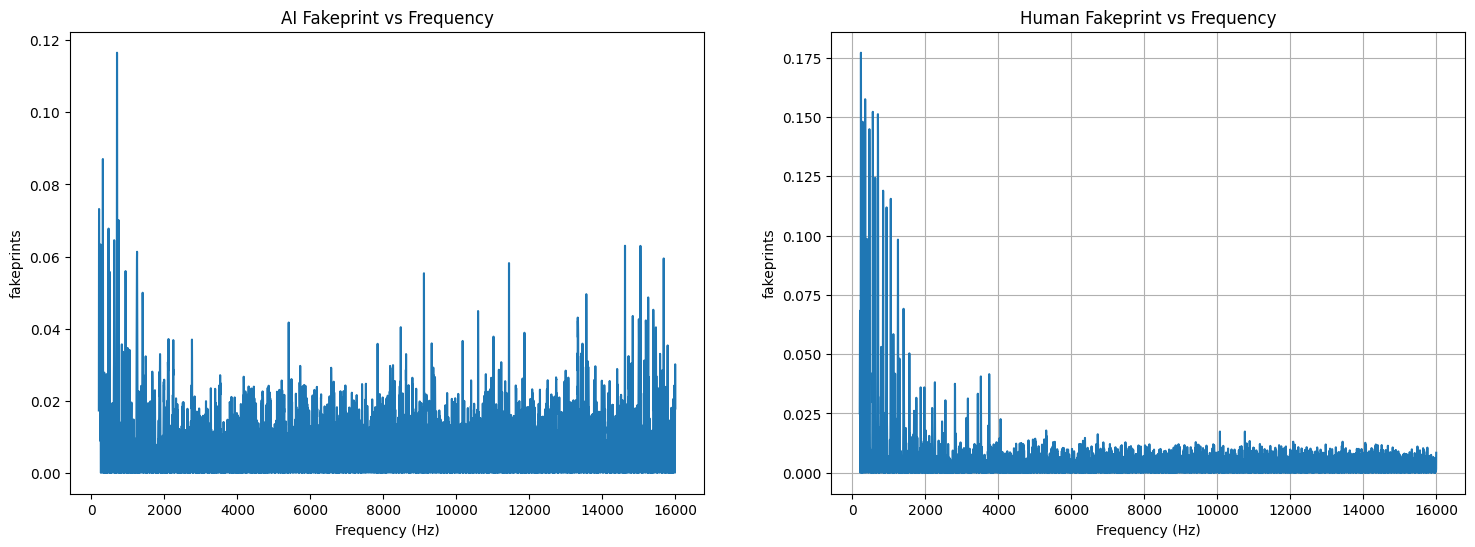

In [2]:
# plot fakeprint
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
for i, fp in enumerate(ai_fps_norm):
    plt.plot(freqs, fp, label=f"AI Fakeprint {i+1}")
#plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("fakeprints")
plt.title("AI Fakeprint vs Frequency")

plt.subplot(1, 2, 2)
for i, fp in enumerate(human_fps_norm):
    plt.plot(freqs, fp, label=f"Human Fakeprint {i+1}")
#plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("fakeprints")
plt.title("Human Fakeprint vs Frequency")

plt.grid()

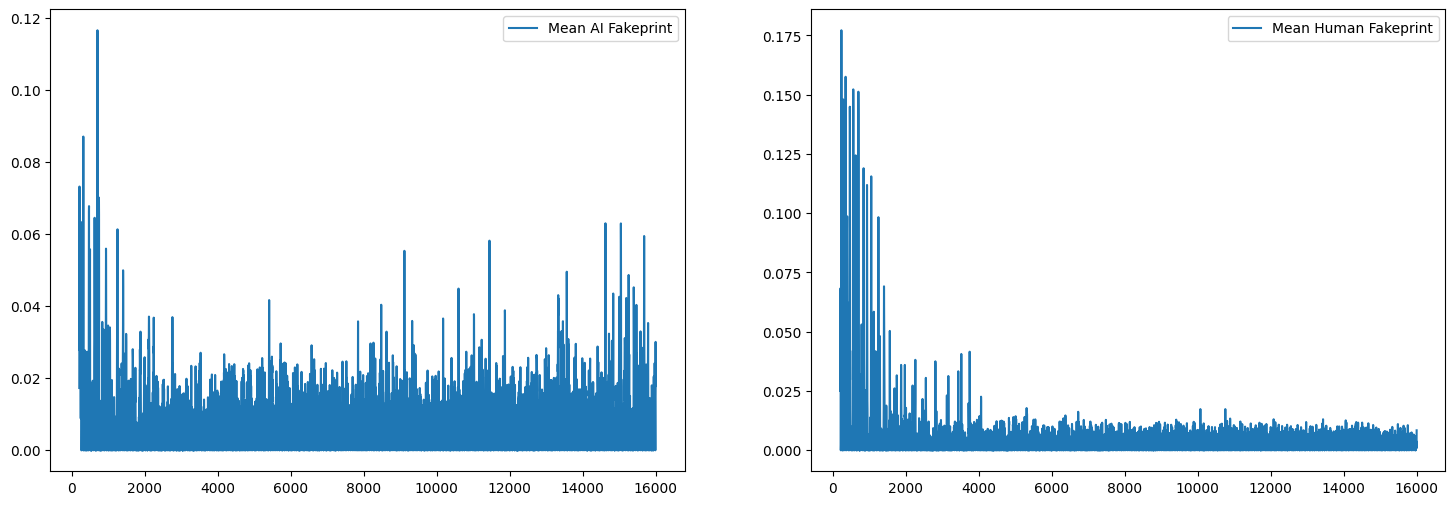

In [3]:
ai_mean_fp = ai_fps_norm.mean(axis=0)
human_mean_fp = human_fps_norm.mean(axis=0)
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.plot(freqs, ai_mean_fp, label="Mean AI Fakeprint")
#plt.xscale("log")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs, human_mean_fp, label="Mean Human Fakeprint")
#plt.xscale("log")
plt.legend()
plt.show()

/var/folders/v0/9w71695x59d8qh46v2htqnm80000gn/T/ipykernel_49002/1809689452.py:2: RuntimeWarning: Degrees of freedom <= 0 for slice
  ai_cov_matrix = np.cov(ai_fps_norm.T)  # (F, F)
/Users/emiledugelay/Machine-Learning/deezer/robust-deepfake-detector/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/emiledugelay/Machine-Learning/deezer/robust-deepfake-detector/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/var/folders/v0/9w71695x59d8qh46v2htqnm80000gn/T/ipykernel_49002/1809689452.py:5: RuntimeWarning: Degrees of freedom <= 0 for slice
  human_cov_matrix = np.cov(human_fps_norm.T)  # (F, F)


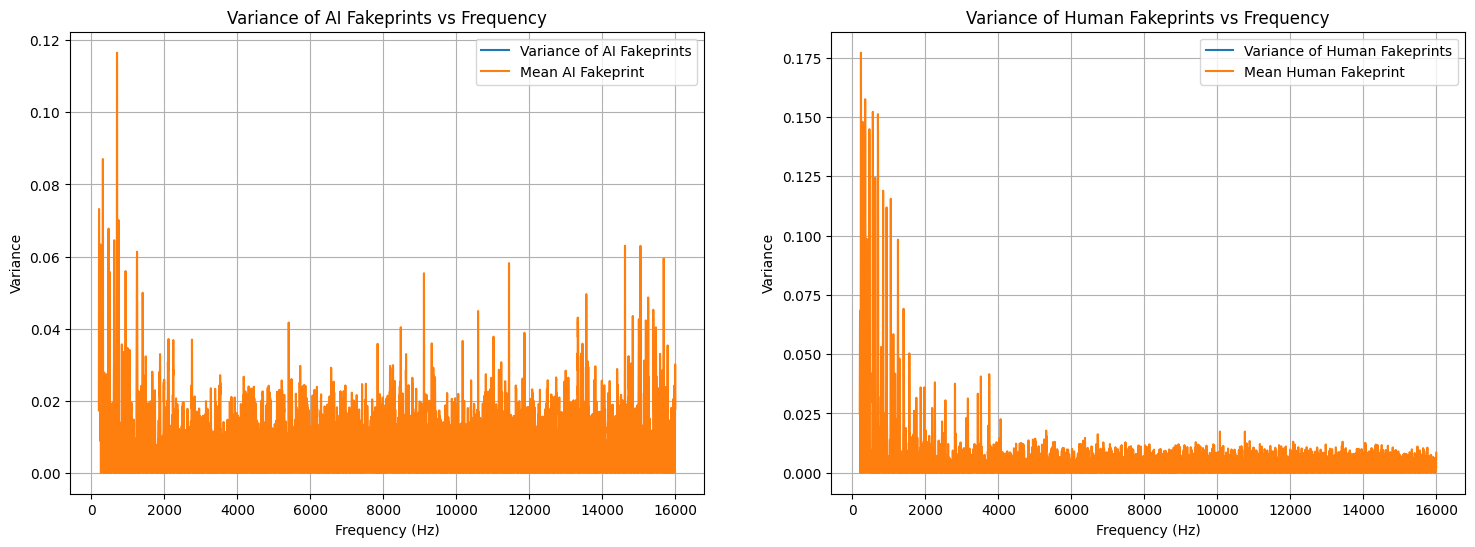

In [4]:
# compute variances/covariances
ai_cov_matrix = np.cov(ai_fps_norm.T)  # (F, F)
ai_variances = np.diag(ai_cov_matrix)  # (F,)

human_cov_matrix = np.cov(human_fps_norm.T)  # (F, F)
human_variances = np.diag(human_cov_matrix)  # (F,)

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.plot(freqs, ai_variances, label="Variance of AI Fakeprints")
plt.plot(freqs, ai_mean_fp, label="Mean AI Fakeprint")
#plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Variance")
plt.title("Variance of AI Fakeprints vs Frequency")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freqs, human_variances, label="Variance of Human Fakeprints")
plt.plot(freqs, human_mean_fp, label="Mean Human Fakeprint")
#plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Variance")
plt.title("Variance of Human Fakeprints vs Frequency")
plt.grid()
plt.legend()

plt.show()

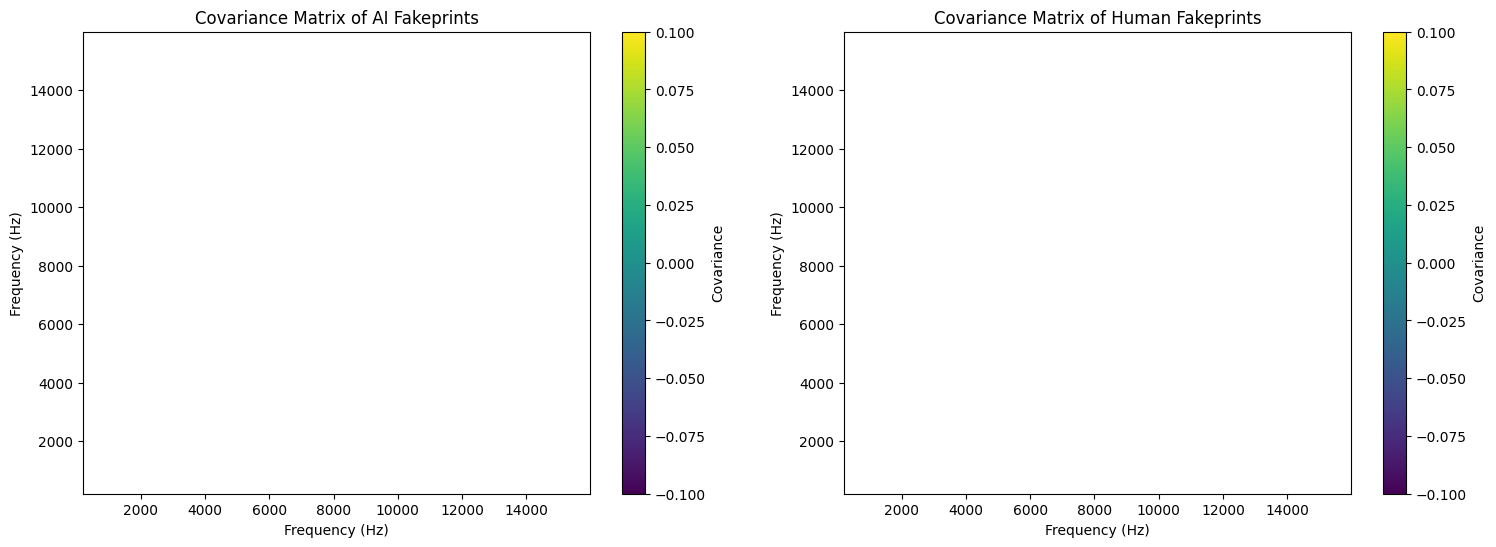

In [5]:
# plot covariances
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.imshow(ai_cov_matrix, aspect="auto", origin="lower", extent=[freqs.min(), freqs.max(), freqs.min(), freqs.max()])
# plt.xscale("log")
# plt.yscale("log")
plt.colorbar(label="Covariance")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Frequency (Hz)")
plt.title("Covariance Matrix of AI Fakeprints")

plt.subplot(1, 2, 2)
plt.imshow(human_cov_matrix, aspect="auto", origin="lower", extent=[freqs.min(), freqs.max(), freqs.min(), freqs.max()])
# plt.xscale("log")
# plt.yscale("log")
plt.colorbar(label="Covariance")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Frequency (Hz)")
plt.title("Covariance Matrix of Human Fakeprints")

plt.show()

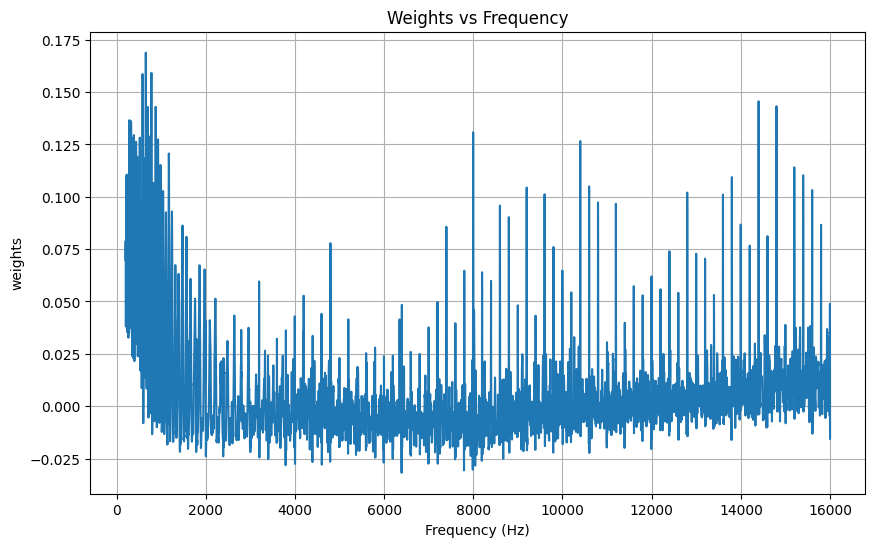

In [6]:
# plot fakeprint
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(freqs, weights, label="Fakeprint")
#plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("weights")
plt.title("Weights vs Frequency")
plt.grid()

/var/folders/v0/9w71695x59d8qh46v2htqnm80000gn/T/ipykernel_49002/4140536463.py:3: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1032.)
  ai_cc = F.conv1d(torch.tensor(ai_fp[None, None, :]), torch.tensor(ai_mean_fp[None, None, :]), padding='same')


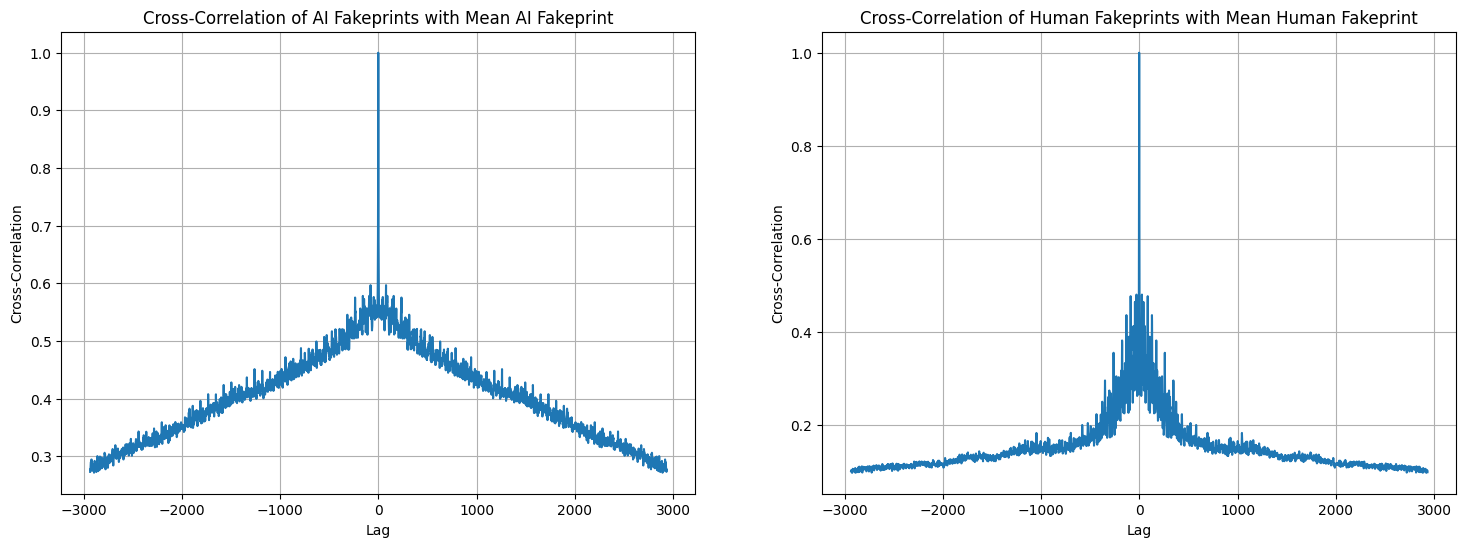

In [7]:
ai_ccs = []
for ai_fp in ai_fps_norm:
    ai_cc = F.conv1d(torch.tensor(ai_fp[None, None, :]), torch.tensor(ai_mean_fp[None, None, :]), padding='same')
    ai_ccs.append(ai_cc.squeeze())
ai_ccs = np.array(ai_ccs)

human_ccs = []
for human_fp in human_fps_norm:
    human_cc = F.conv1d(torch.tensor(human_fp[None, None, :]), torch.tensor(human_mean_fp[None, None, :]), padding='same')
    human_ccs.append(human_cc.squeeze())
human_ccs = np.array(human_ccs)

lag = np.arange(-len(ai_mean_fp) // 2, len(ai_mean_fp) // 2)

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
for i, ai_cc in enumerate(ai_ccs):
    plt.plot(lag, ai_cc, label=f"AI Cross-Correlation {i+1}")
plt.xlabel("Lag")
plt.ylabel("Cross-Correlation")
plt.title("Cross-Correlation of AI Fakeprints with Mean AI Fakeprint")
plt.grid()

plt.subplot(1, 2, 2)
for i, human_cc in enumerate(human_ccs):
    plt.plot(lag, human_cc, label=f"Human Cross-Correlation {i+1}")
plt.xlabel("Lag")
plt.ylabel("Cross-Correlation")
plt.title("Cross-Correlation of Human Fakeprints with Mean Human Fakeprint")
plt.grid()

plt.show()

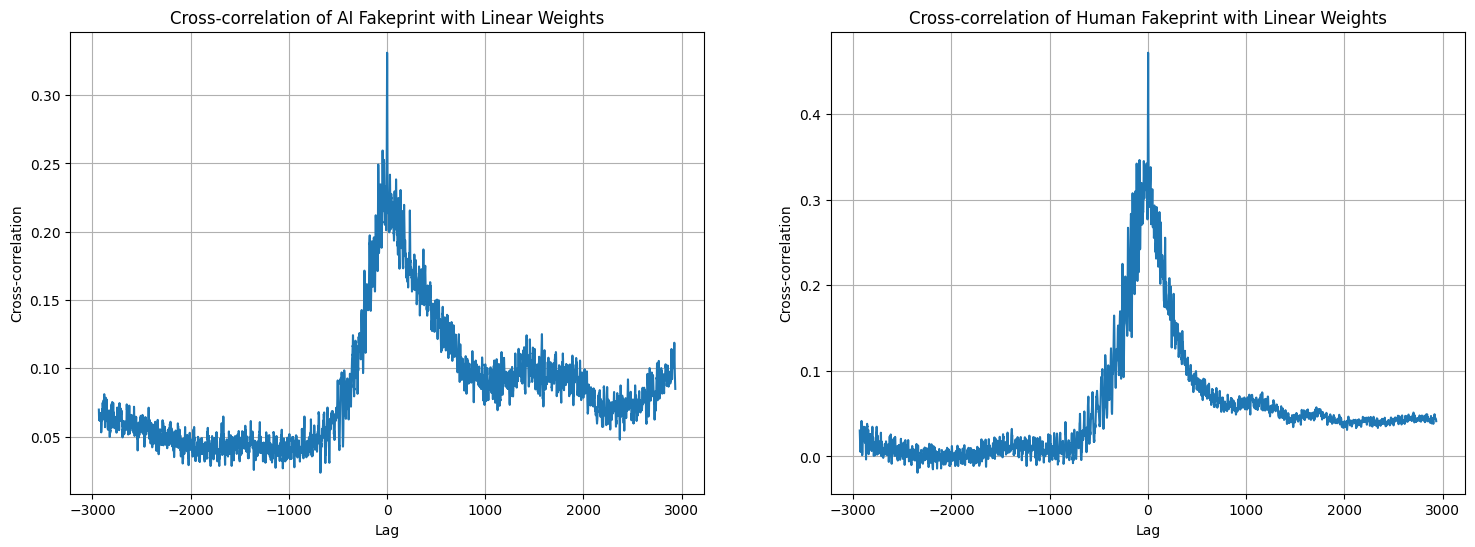

In [8]:
with torch.inference_mode():
    ai_logits, ai_cross_corrs = model(torch.from_numpy(ai_fps_norm).to(next(model.parameters()).device), convolve=True)
    human_logits, human_cross_corrs = model(torch.from_numpy(human_fps_norm).to(next(model.parameters()).device), convolve=True)
    ai_cross_corrs = ai_cross_corrs.squeeze(1).detach().cpu().numpy()
    human_cross_corrs = human_cross_corrs.squeeze(1).detach().cpu().numpy()

lag = torch.arange(-ai_cross_corrs.shape[-1] // 2 + 1, ai_cross_corrs.shape[-1] // 2 + 1)

# plot cross-correlation
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
for i, cross_corr in enumerate(ai_cross_corrs):
    plt.plot(lag, cross_corr, label=f"Cross-correlation {i+1}")
plt.xlabel("Lag")
plt.ylabel("Cross-correlation")
plt.title("Cross-correlation of AI Fakeprint with Linear Weights")
plt.grid()

plt.subplot(1, 2, 2)
for i, cross_corr in enumerate(human_cross_corrs):
    plt.plot(lag, cross_corr, label=f"Cross-correlation {i+1}")
plt.xlabel("Lag")
plt.ylabel("Cross-correlation")
plt.title("Cross-correlation of Human Fakeprint with Linear Weights")
plt.grid()

plt.show()